In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Daily Household Transactions.csv')

In [3]:
df.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [4]:
df.shape

(2461, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


In [6]:
df.isnull().sum()

Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64

In [7]:
df['Subcategory'].fillna("Unknown",inplace = True)
df['Note'].fillna("No Note",inplace = True)

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format = 'mixed', dayfirst = True)

In [9]:
df['Date'].unique()

<DatetimeArray>
['2018-09-20 12:04:08', '2018-09-20 12:03:15', '2018-09-19 00:00:00',
 '2018-09-17 23:41:17', '2018-09-16 17:15:08', '2018-09-15 06:34:17',
 '2018-09-14 05:39:17', '2018-09-13 21:35:15', '2018-09-13 21:01:47',
 '2018-09-13 21:01:32',
 ...
 '2015-01-10 00:00:00', '2015-01-09 00:00:00', '2015-01-08 00:00:00',
 '2015-01-07 00:00:00', '2015-01-06 00:00:00', '2015-01-05 00:00:00',
 '2015-01-04 00:00:00', '2015-01-03 00:00:00', '2015-01-02 00:00:00',
 '2015-01-01 00:00:00']
Length: 1611, dtype: datetime64[ns]

In [10]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day

In [11]:
df.isnull().sum()

Date              0
Mode              0
Category          0
Subcategory       0
Note              0
Amount            0
Income/Expense    0
Currency          0
Year              0
Month             0
Month_Name        0
Day               0
dtype: int64

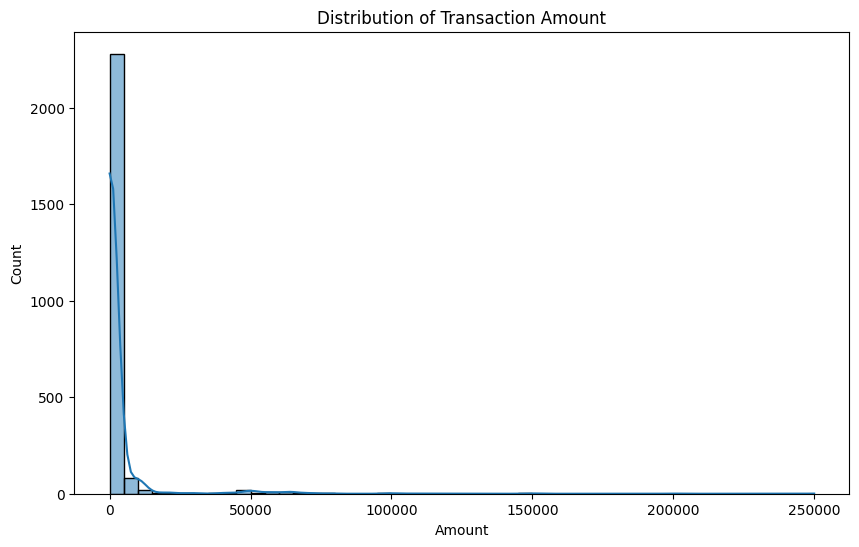

In [12]:
# Exploratory Data Analysis (EDA)

# Distribution of Transaction Amount
plt.figure(figsize=(10,6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.show()

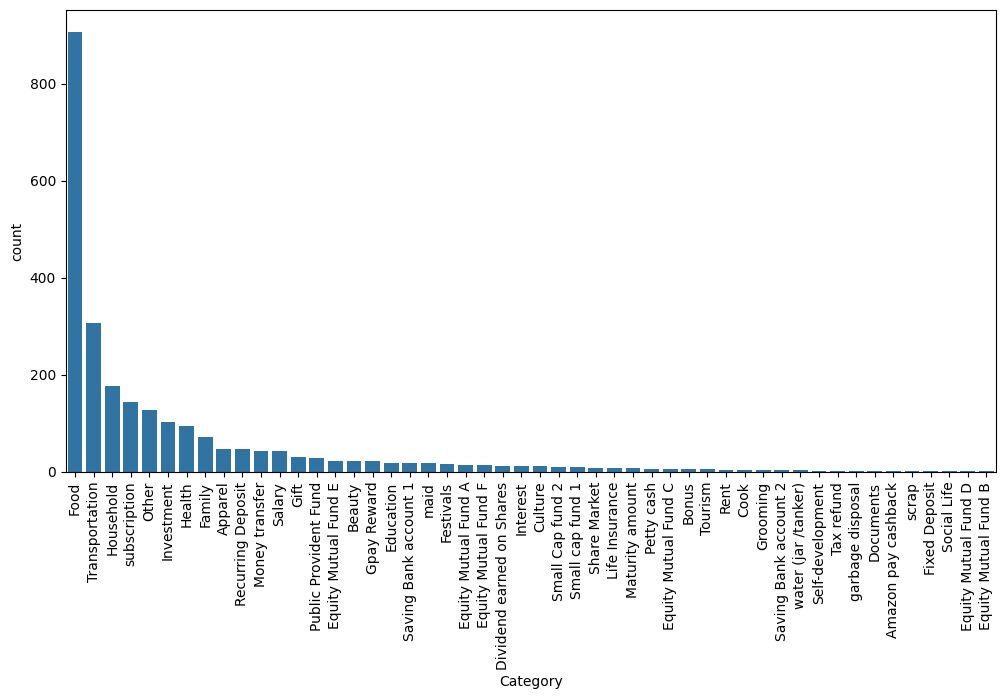

In [13]:
# Transaction Count by Category

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Category",
              order=df['Category'].value_counts().index)

plt.xticks(rotation=90)
plt.show()

In [14]:
# Payment Mode Analysis
df['Mode'].value_counts()

Mode
Saving Bank account 1    1223
Cash                     1046
Credit Card               162
Equity Mutual Fund B       11
Share Market Trading        5
Saving Bank account 2       5
Recurring Deposit           3
Debit Card                  2
Equity Mutual Fund C        1
Equity Mutual Fund A        1
Equity Mutual Fund D        1
Fixed Deposit               1
Name: count, dtype: int64

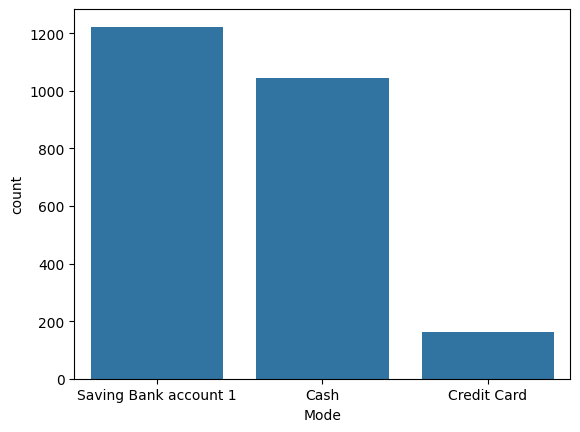

In [15]:
sns.countplot(data=df, x="Mode",
              order=df['Mode'].value_counts().iloc[:3].index)
plt.show()

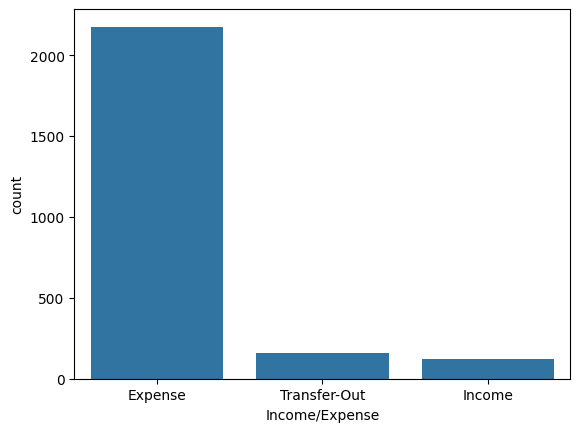

In [16]:
# Income vs Expense Analysis
sns.countplot(data=df, x="Income/Expense")
plt.show()

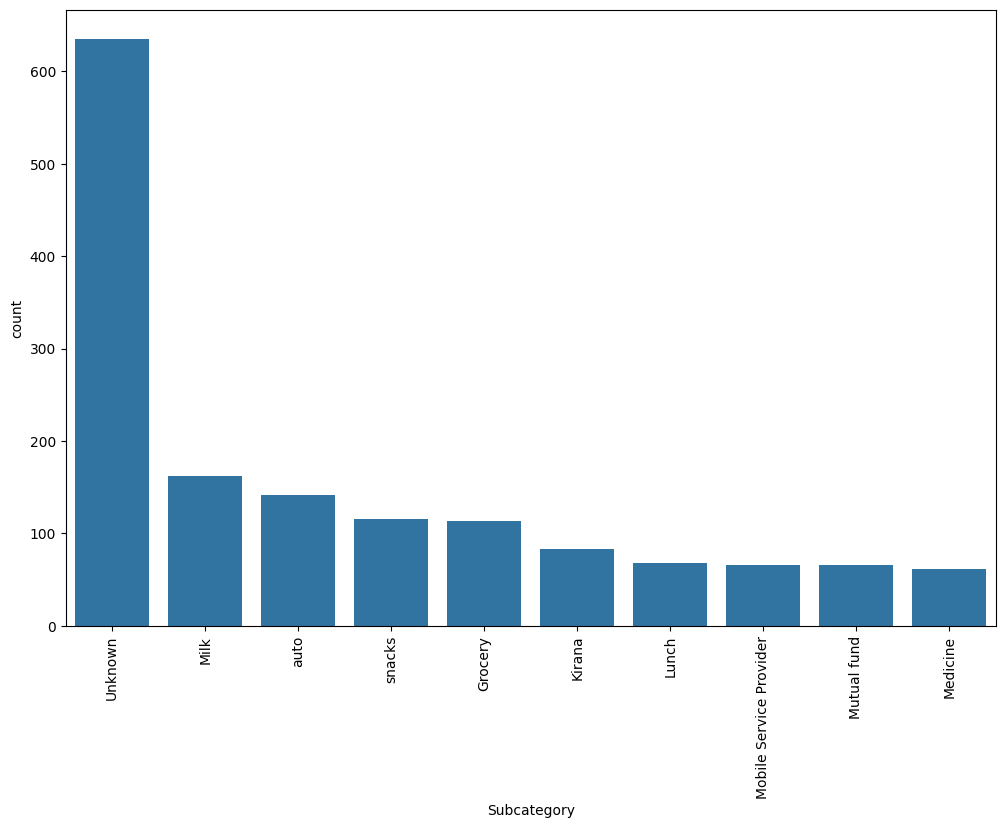

In [17]:
# Top Subcategories
plt.figure(figsize=(12,8))
sns.countplot(data=df, x="Subcategory",
              order=df['Subcategory'].value_counts().iloc[:10].index)

plt.xticks(rotation=90)
plt.show()

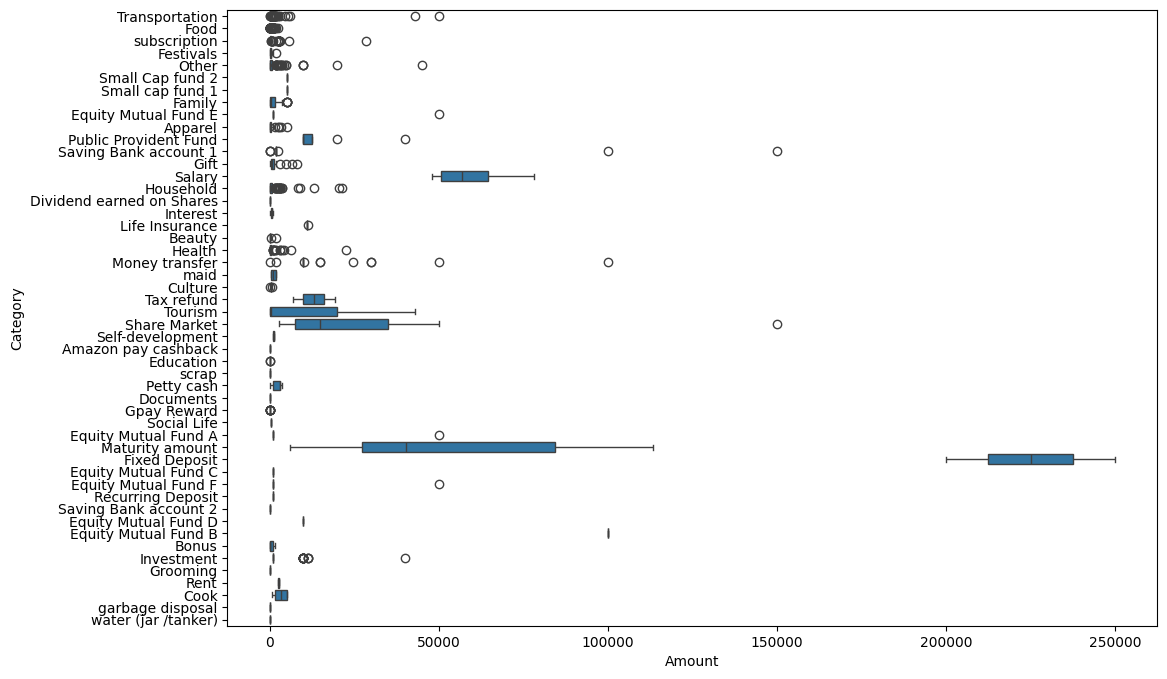

In [18]:
# Boxplot for Spending
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x="Amount", y="Category")
plt.show()

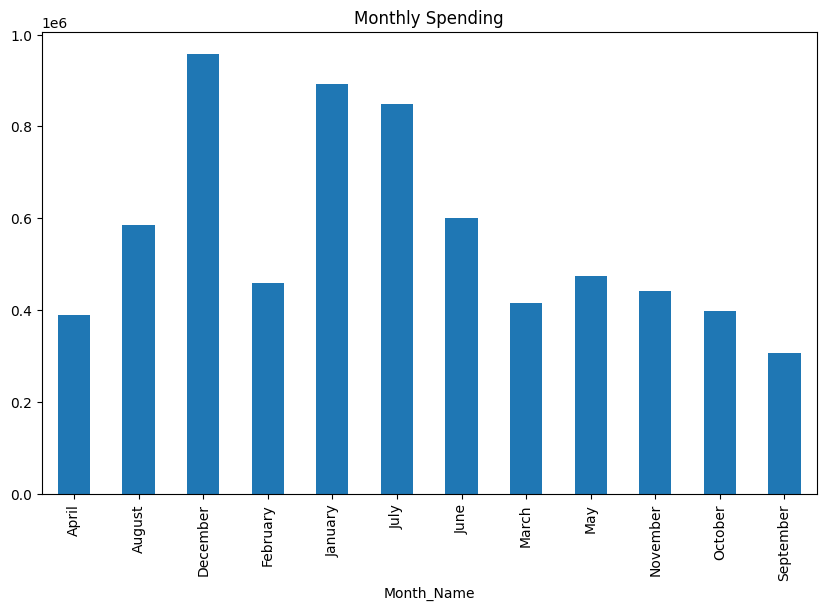

In [19]:
# Time Series Analysis
monthly_spending = df.groupby('Month_Name')['Amount'].sum()

monthly_spending.plot(kind='bar', figsize=(10,6))
plt.title("Monthly Spending")
plt.show()